In [24]:
import os
import io
import random
import zipfile
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

DATA_PATH = "playground-series-s6e4.zip" 

with zipfile.ZipFile(DATA_PATH, "r") as z:
    train = pd.read_csv(z.open("train.csv"))
    test = pd.read_csv(z.open("test.csv"))
    sample_submission = pd.read_csv(z.open("sample_submission.csv"))

In [25]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [26]:
train.shape

(630000, 21)

In [27]:
test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [28]:
test.shape

(270000, 20)

In [29]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [30]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [31]:
train.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [32]:
test.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
dtype: int64

In [33]:
target_col = 'Irrigation_Need'

feature_cols = [c for c in train.columns if c != target_col and c != 'id']

numeric_cols = train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print("\n数值型特征数量:", len(numeric_cols))
print("分类型特征数量:", len(categorical_cols))

if len(numeric_cols) > 0:
    print("\n数值型特征:")
    print(numeric_cols)

if len(categorical_cols) > 0:
    print("\n分类型特征:")
    print(categorical_cols)


数值型特征数量: 11
分类型特征数量: 8

数值型特征:
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

分类型特征:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


In [34]:
# # ---------- 直方图 ----------
# n_cols = 4
# n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
# axes = np.array(axes).reshape(-1)

# for i, col in enumerate(numeric_cols):
#     sns.histplot(train[col], bins=30, kde=True, ax=axes[i])
#     axes[i].set_title(f"Histogram of {col}")
#     axes[i].set_xlabel(col)

# for j in range(i + 1, len(axes)):
#     axes[j].axis("off")

# plt.tight_layout()
# plt.show()

In [35]:
# n_cols = 4
# n_rows = int(np.ceil(len(categorical_cols) / n_cols))

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows))
# axes = np.array(axes).reshape(-1)

# for i, col in enumerate(categorical_cols):
#     plot_data = train[col].astype(str).value_counts(dropna=False)

#     sns.barplot(x=plot_data.index, y=plot_data.values, ax=axes[i])
#     axes[i].set_title(f"Bar Plot of {col}")
#     axes[i].set_xlabel(col)
#     axes[i].set_ylabel("Count")
#     axes[i].tick_params(axis="x", rotation=45)

# for j in range(i + 1, len(axes)):
#     axes[j].axis("off")

# plt.tight_layout()
# plt.show()

In [36]:
# plt.figure(figsize=(8, 5))
# sns.countplot(x=train[target_col])
# plt.title(f"Target Distribution: {target_col}")
# plt.xlabel(target_col)
# plt.ylabel("Count")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [37]:
# n_cols = 4
# n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
# axes = np.array(axes).reshape(-1)

# for i, col in enumerate(numeric_cols):
#     sns.boxplot(x=train[col], ax=axes[i])
#     axes[i].set_title(f"Boxplot of {col}")
#     axes[i].set_xlabel(col)

# for j in range(i + 1, len(axes)):
#     axes[j].axis("off")

# plt.tight_layout()
# plt.show()

In [38]:
# from scipy.stats import boxcox

# for col in numeric_cols:
#     x = train[col].dropna().astype(float)

#     shift = 0.0
#     if x.min() <= 0:
#         shift = 1 - x.min()

#     x_shifted = x + shift

#     # 1) 原始数据
#     x_raw = x

#     # 2) log 变换
#     x_log = np.log(x_shifted)

#     # 3) sqrt 变换
#     x_sqrt = np.sqrt(x_shifted)

#     # 4) box-cox 变换
#     x_boxcox, best_lambda = boxcox(x_shifted)

#     # ---------- 作图 ----------
#     fig, axes = plt.subplots(2, 2, figsize=(14, 10))
#     axes = axes.ravel()

#     sns.histplot(x_raw, bins=30, kde=True, ax=axes[0])
#     axes[0].set_title(f"{col} - Original")

#     sns.histplot(x_log, bins=30, kde=True, ax=axes[1])
#     if shift != 0:
#         axes[1].set_title(f"{col} - Log (shift={shift:.4f})")
#     else:
#         axes[1].set_title(f"{col} - Log")

#     sns.histplot(x_sqrt, bins=30, kde=True, ax=axes[2])
#     if shift != 0:
#         axes[2].set_title(f"{col} - Sqrt (shift={shift:.4f})")
#     else:
#         axes[2].set_title(f"{col} - Sqrt")

#     sns.histplot(x_boxcox, bins=30, kde=True, ax=axes[3])
#     if shift != 0:
#         axes[3].set_title(f"{col} - Box-Cox (lambda={best_lambda:.4f}, shift={shift:.4f})")
#     else:
#         axes[3].set_title(f"{col} - Box-Cox (lambda={best_lambda:.4f})")

#     plt.suptitle(f"Distribution Transformations of {col}", fontsize=14, y=1.02)
#     plt.tight_layout()
#     plt.show()

In [39]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    log_loss,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE


# =========================
# 1. 特征工程（train/test 同步）
# =========================
def add_features(df):
    df = df.copy()

    # 数值交叉 / 比例特征
    df["temp_x_sun"] = df["Temperature_C"] * df["Sunlight_Hours"]
    df["temp_x_wind"] = df["Temperature_C"] * df["Wind_Speed_kmh"]
    df["temp_humidity_ratio"] = df["Temperature_C"] / (df["Humidity"] + 1)
    df["sun_humidity_ratio"] = df["Sunlight_Hours"] / (df["Humidity"] + 1)
    df["water_input_total"] = df["Rainfall_mm"] + df["Previous_Irrigation_mm"]
    df["water_vs_temp"] = (df["Rainfall_mm"] + df["Previous_Irrigation_mm"]) / (df["Temperature_C"] + 1)
    df["soil_orgc_interaction"] = df["Soil_Moisture"] * df["Organic_Carbon"]
    df["soil_temp_interaction"] = df["Soil_Moisture"] * df["Temperature_C"]
    df["field_irrigation_ratio"] = df["Previous_Irrigation_mm"] / (df["Field_Area_hectare"] + 1e-6)
    df["evap_stress_proxy"] = (
        df["Temperature_C"] * df["Sunlight_Hours"] * df["Wind_Speed_kmh"]
    ) / (df["Humidity"] + 1)

    # 分类交叉特征
    df["Crop_Stage"] = df["Crop_Type"].astype(str) + "_" + df["Crop_Growth_Stage"].astype(str)
    df["Season_Region"] = df["Season"].astype(str) + "_" + df["Region"].astype(str)
    df["Irrigation_Water"] = df["Irrigation_Type"].astype(str) + "_" + df["Water_Source"].astype(str)

    return df


train = add_features(train)
test = add_features(test)

feature_cols = [c for c in train.columns if c not in [target_col, "id"]]

numeric_cols = train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print("=" * 80)
print("特征工程完成后：")
print("总特征数量:", len(feature_cols))
print("数值型特征数量:", len(numeric_cols))
print("分类型特征数量:", len(categorical_cols))

print("\n全部特征名称：")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:>2}. {col}")

特征工程完成后：
总特征数量: 32
数值型特征数量: 21
分类型特征数量: 11

全部特征名称：
 1. Soil_Type
 2. Soil_pH
 3. Soil_Moisture
 4. Organic_Carbon
 5. Electrical_Conductivity
 6. Temperature_C
 7. Humidity
 8. Rainfall_mm
 9. Sunlight_Hours
10. Wind_Speed_kmh
11. Crop_Type
12. Crop_Growth_Stage
13. Season
14. Irrigation_Type
15. Water_Source
16. Field_Area_hectare
17. Mulching_Used
18. Previous_Irrigation_mm
19. Region
20. temp_x_sun
21. temp_x_wind
22. temp_humidity_ratio
23. sun_humidity_ratio
24. water_input_total
25. water_vs_temp
26. soil_orgc_interaction
27. soil_temp_interaction
28. field_irrigation_ratio
29. evap_stress_proxy
30. Crop_Stage
31. Season_Region
32. Irrigation_Water


In [40]:
X = train[feature_cols].copy()
y = train[target_col].copy()
X_test_final = test[feature_cols].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
n_classes = len(class_names)

print("\n类别标签：", list(class_names))
print("类别数量：", n_classes)

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)
X_train_raw


类别标签： ['High', 'Low', 'Medium']
类别数量： 3


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,sun_humidity_ratio,water_input_total,water_vs_temp,soil_orgc_interaction,soil_temp_interaction,field_irrigation_ratio,evap_stress_proxy,Crop_Stage,Season_Region,Irrigation_Water
344420,Silt,5.66,51.38,0.46,1.46,33.21,66.34,775.35,6.23,17.09,...,0.092516,841.97,24.611809,23.6348,1706.3298,4.887747,52.508048,Maize_Flowering,Zaid_Central,Canal_Reservoir
29017,Loamy,6.14,8.03,1.14,3.34,20.85,74.29,2374.11,7.52,1.94,...,0.099880,2466.35,112.876430,9.1542,167.4255,16.589925,4.040065,Sugarcane_Vegetative,Rabi_West,Rainfed_Groundwater
570499,Sandy,5.77,59.04,1.08,0.55,14.44,37.99,2137.79,5.05,10.46,...,0.129520,2230.10,144.436528,63.7632,852.5376,118.346002,19.563071,Rice_Sowing,Rabi_South,Drip_Reservoir
620696,Sandy,5.06,63.19,1.59,1.10,23.58,58.25,1226.78,4.54,1.15,...,0.076624,1340.14,54.521562,100.4721,1490.0202,42.456913,2.077826,Wheat_Harvest,Kharif_West,Canal_Reservoir
7445,Clay,6.28,35.94,1.11,1.57,34.30,71.04,2266.39,8.47,16.81,...,0.117574,2363.29,66.948725,39.8934,1232.7420,14.376852,67.790922,Maize_Vegetative,Kharif_North,Drip_Groundwater
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277637,Silt,5.38,19.61,0.71,1.67,19.59,53.29,898.55,5.58,9.79,...,0.102781,1010.29,49.067023,13.9231,384.1599,9.941280,19.712036,Maize_Flowering,Kharif_Central,Rainfed_Groundwater
252995,Clay,6.36,49.43,0.64,0.76,39.35,80.03,1456.00,5.38,15.12,...,0.066395,1498.02,37.125651,31.6352,1945.0705,4.567391,39.503262,Sugarcane_Vegetative,Kharif_North,Canal_River
289442,Clay,7.55,56.06,0.92,2.29,39.95,68.13,1852.17,4.44,9.52,...,0.064227,1933.63,47.219292,51.5752,2239.5970,11.874634,24.427001,Sugarcane_Flowering,Zaid_East,Drip_Reservoir
386692,Clay,6.21,57.52,0.79,3.18,15.79,54.86,2490.57,6.65,2.59,...,0.119048,2506.82,149.304348,45.4408,908.2408,2.821180,4.868583,Wheat_Vegetative,Kharif_North,Canal_River


In [41]:
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_enc = X_train_raw.copy()
X_valid_enc = X_valid_raw.copy()
X_test_enc = X_test_final.copy()

X_train_enc[categorical_cols] = encoder.fit_transform(X_train_raw[categorical_cols])
X_valid_enc[categorical_cols] = encoder.transform(X_valid_raw[categorical_cols])
X_test_enc[categorical_cols] = encoder.transform(X_test_final[categorical_cols])

for col in X_train_enc.columns:
    X_train_enc[col] = pd.to_numeric(X_train_enc[col], errors="coerce")
    X_valid_enc[col] = pd.to_numeric(X_valid_enc[col], errors="coerce")
    X_test_enc[col] = pd.to_numeric(X_test_enc[col], errors="coerce")

In [42]:
rf_selector = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_selector.fit(X_train_enc, y_train)

rf_importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

rf_importance_df = rf_importance.reset_index()
rf_importance_df.columns = ["feature", "importance"]

print("\n" + "=" * 80)
print("RF 特征重要性 Top 20：")
rf_importance_df.head(20)


RF 特征重要性 Top 20：


,feature,importance
0,Crop_Growth_Stage,0.174133
1,Soil_Moisture,0.160930
2,Mulching_Used,0.094952
3,Temperature_C,0.081711
4,temp_x_wind,0.071751
5,soil_temp_interaction,0.063641
6,Wind_Speed_kmh,0.050734
7,Rainfall_mm,0.044866
8,water_input_total,0.039372
9,water_vs_temp,0.037876


In [43]:
TOP_K = min(20, len(rf_importance_df))
selected_features = rf_importance_df.head(TOP_K)["feature"].tolist()

print(f"\nRF筛选后保留的特征数量: {len(selected_features)}")
print("RF筛选后的特征名称：")
for i, col in enumerate(selected_features, 1):
    print(f"{i:>2}. {col}")

X_train_sel = X_train_enc[selected_features].copy()
X_valid_sel = X_valid_enc[selected_features].copy()
X_test_sel = X_test_enc[selected_features].copy()


RF筛选后保留的特征数量: 20
RF筛选后的特征名称：
 1. Crop_Growth_Stage
 2. Soil_Moisture
 3. Mulching_Used
 4. Temperature_C
 5. temp_x_wind
 6. soil_temp_interaction
 7. Wind_Speed_kmh
 8. Rainfall_mm
 9. water_input_total
10. water_vs_temp
11. soil_orgc_interaction
12. evap_stress_proxy
13. Crop_Stage
14. temp_humidity_ratio
15. temp_x_sun
16. Humidity
17. Previous_Irrigation_mm
18. Organic_Carbon
19. Sunlight_Hours
20. sun_humidity_ratio


In [44]:
print("\n" + "=" * 80)
print("SMOTE 前训练集类别分布：")
print(pd.Series(y_train).value_counts().sort_index())

smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sel, y_train)

print("\nSMOTE 后训练集类别分布：")
print(pd.Series(y_train_smote).value_counts().sort_index())
print("SMOTE 后训练集形状:", X_train_smote.shape)


SMOTE 前训练集类别分布：
0     16807
1    295934
2    191259
Name: count, dtype: int64

SMOTE 后训练集类别分布：
0    295934
1    295934
2    295934
Name: count, dtype: int64
SMOTE 后训练集形状: (887802, 20)


In [46]:
lgb_model = LGBMClassifier(
    objective="multiclass",
    num_class=n_classes,
    n_estimators=1000,
    learning_rate=0.001,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)
eval_metric = "multi_logloss"


lgb_model.fit(
    X_train_smote,
    y_train_smote,
    eval_set=[(X_train_sel, y_train), (X_valid_sel, y_valid)],
    eval_metric=eval_metric,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

[100]	valid_0's multi_logloss: 0.96688	valid_1's multi_logloss: 0.966981
[200]	valid_0's multi_logloss: 0.857011	valid_1's multi_logloss: 0.857164
[300]	valid_0's multi_logloss: 0.764384	valid_1's multi_logloss: 0.764575
[400]	valid_0's multi_logloss: 0.686151	valid_1's multi_logloss: 0.686326
[500]	valid_0's multi_logloss: 0.617984	valid_1's multi_logloss: 0.618145
[600]	valid_0's multi_logloss: 0.557856	valid_1's multi_logloss: 0.55798
[700]	valid_0's multi_logloss: 0.506186	valid_1's multi_logloss: 0.506275
[800]	valid_0's multi_logloss: 0.461362	valid_1's multi_logloss: 0.461388
[900]	valid_0's multi_logloss: 0.421359	valid_1's multi_logloss: 0.42133
[1000]	valid_0's multi_logloss: 0.385869	valid_1's multi_logloss: 0.385779


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.001, n_estimators=1000,
               n_jobs=-1, num_class=3, objective='multiclass', random_state=42,
               reg_alpha=0.1, reg_lambda=0.1, subsample=0.8, verbosity=-1)

In [47]:
train_pred = lgb_model.predict(X_train_sel)
valid_pred = lgb_model.predict(X_valid_sel)

train_proba = lgb_model.predict_proba(X_train_sel)
valid_proba = lgb_model.predict_proba(X_valid_sel)

train_bal_acc = balanced_accuracy_score(y_train, train_pred)
valid_bal_acc = balanced_accuracy_score(y_valid, valid_pred)

train_loss = log_loss(y_train, train_proba, labels=np.arange(n_classes))
valid_loss = log_loss(y_valid, valid_proba, labels=np.arange(n_classes))

print("\n" + "=" * 80)
print("LightGBM 模型评估结果")
print(f"Train Balanced Accuracy : {train_bal_acc:.6f}")
print(f"Valid Balanced Accuracy : {valid_bal_acc:.6f}")
print(f"Train Log Loss         : {train_loss:.6f}")
print(f"Valid Log Loss         : {valid_loss:.6f}")


LightGBM 模型评估结果
Train Balanced Accuracy : 0.957732
Valid Balanced Accuracy : 0.959583
Train Log Loss         : 0.385869
Valid Log Loss         : 0.385779


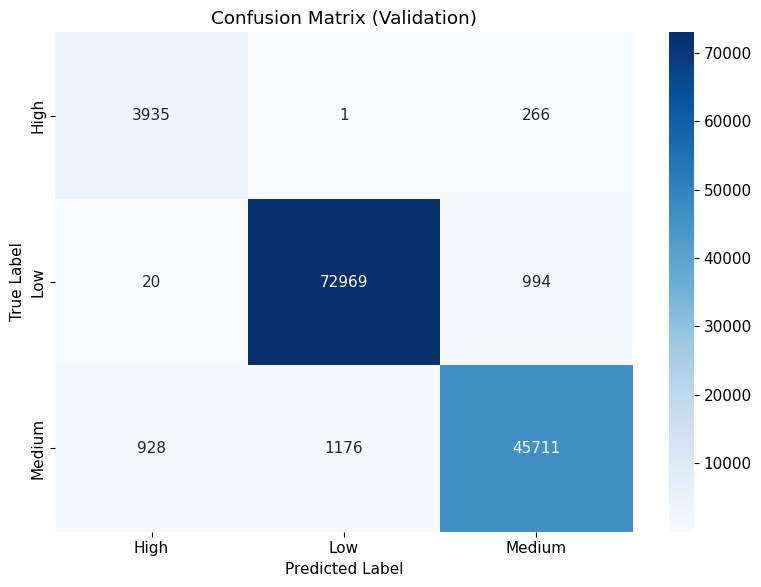

In [48]:
cm = confusion_matrix(y_valid, valid_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

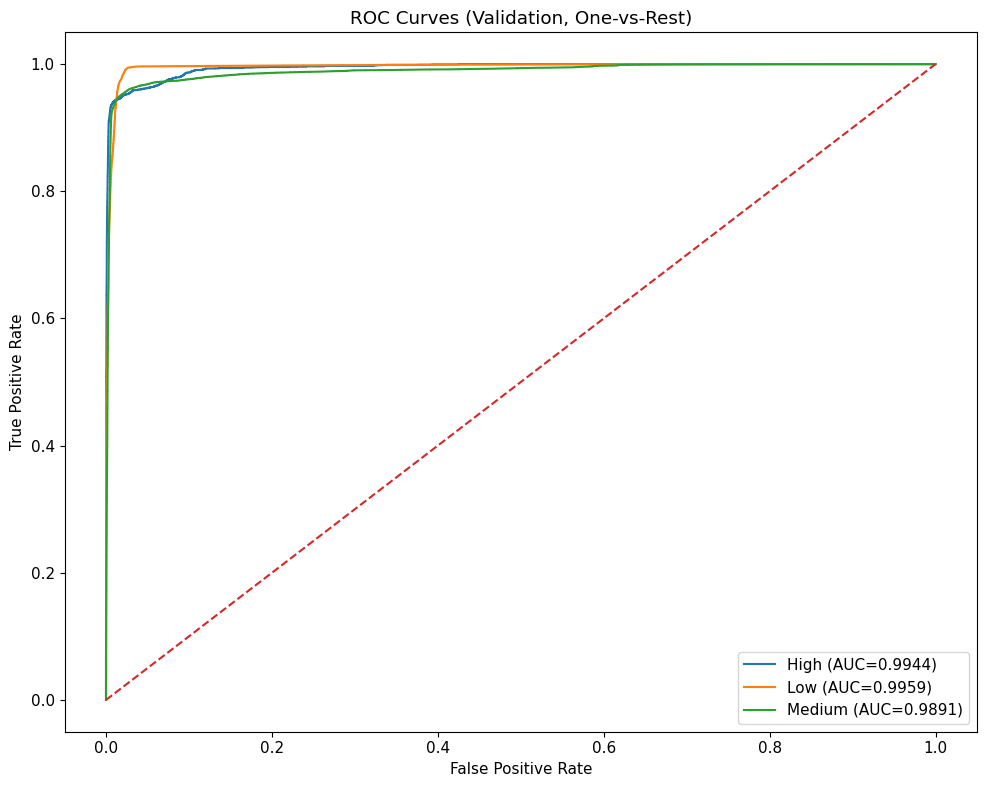


Validation ROC-AUC Macro    : 0.993139
Validation ROC-AUC Weighted : 0.993285


In [49]:
plt.figure(figsize=(10, 8))

y_valid_bin = label_binarize(y_valid, classes=np.arange(n_classes))
auc_macro = roc_auc_score(y_valid_bin, valid_proba, multi_class="ovr", average="macro")
auc_weighted = roc_auc_score(y_valid_bin, valid_proba, multi_class="ovr", average="weighted")

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_valid_bin[:, i], valid_proba[:, i])
    auc_i = roc_auc_score(y_valid_bin[:, i], valid_proba[:, i])
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc_i:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation, One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nValidation ROC-AUC Macro    : {auc_macro:.6f}")
print(f"Validation ROC-AUC Weighted : {auc_weighted:.6f}")

In [50]:
test_pred = lgb_model.predict(X_test_sel)
test_pred_label = label_encoder.inverse_transform(test_pred.astype(int))

sample_submission[target_col] = test_pred_label

print("\n" + "=" * 80)
print("提交文件预览：")
sample_submission.head()


提交文件预览：


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


In [51]:
sample_submission.to_csv("sample_submission.csv", index=False)